<a href="https://colab.research.google.com/github/lfangyu443-ui/digital-mh-nlp-asian-adolescents/blob/main/notebooks/02_text_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**粗體文字**# Notebook 02: Multilingual Text Preprocessing
## Digital Mental Health NLP Pipeline for Asian Adolescents

**Author:** Lin Fang Yu 林芳伃 | MPH Candidate, NUS  
**Date:** May 2026  

### Objectives
This notebook builds the **multilingual text preprocessing pipeline** for Mandarin and English mental health text — the critical data preparation step before feeding text into Chinese MentalBERT (Tier 1 Screening).

We cover:
1. Text cleaning and normalisation (ZH + EN)
2. Traditional → Simplified Chinese conversion
3. Code-switching detection and handling (Singlish/混合語言)
4. jieba tokenisation for Chinese text
5. Stopword removal (bilingual)
6. MentalBERT tokenisation demo
7. Feature extraction pipeline

### Why Preprocessing Matters
Asian adolescents in Singapore write in a unique mix of:
- **Traditional Chinese** (Taiwan influence) and **Simplified Chinese**
- **English** and **Mandarin code-switching**: "好stressed, cannot tahan anymore"
- **Emojis and emoticons**: 😭 🥲 which carry emotional meaning
- **Slang and internet language**: 躺平, emo了, 太难了

Generic NLP preprocessing pipelines miss these patterns entirely.

---


## 0. Setup & Dependencies

In [1]:
# Install required packages
!pip install jieba opencc-python-reimplemented emoji langdetect
!pip install transformers torch
!pip install pandas numpy matplotlib seaborn

print("✅ All packages installed")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 11.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 481.8/481.8 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 16.4 MB/s eta 0:00:00
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=c9051a484a19b508e362f9a14a0c4ffdc279ee9dcebabcab8ae67b9f4660211e
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect
✅ All packages installed


In [2]:
import pandas as pd
import numpy as np
import jieba
import jieba.analyse
import re
import emoji
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Try importing optional packages
try:
    import opencc
    HAS_OPENCC = True
    print("✅ opencc available — Traditional→Simplified conversion enabled")
except ImportError:
    HAS_OPENCC = False
    print("⚠️  opencc not available — skipping T→S conversion")

try:
    from langdetect import detect
    HAS_LANGDETECT = True
    print("✅ langdetect available")
except ImportError:
    HAS_LANGDETECT = False
    print("⚠️  langdetect not available")

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')
print("\n✅ All imports successful")


/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:44: SyntaxWarning: invalid escape sequence '\.'
  re_han_default = re.compile("([\u4E00-\u9FD5a-zA-Z0-9+#&\._%\-]+)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:46: SyntaxWarning: invalid escape sequence '\s'
  re_skip_default = re.compile("(\r\n|\s)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/finalseg/__init__.py:78: SyntaxWarning: invalid escape sequence '\.'
  re_skip = re.compile("([a-zA-Z0-9]+(?:\.\d+)?%?)")
/usr/local/lib/python3.12/dist-packages/jieba/posseg/__init__.py:16: SyntaxWarning: invalid escape sequence '\.'
  re_skip_detail = re.compile("([\.0-9]+|[a-zA-Z0-9]+)")
/usr/local/lib/python3.12/dist-packages/jieba/posseg/__init__.py:17: SyntaxWarning: invalid escape sequence '\.'
  re_han_internal = re.compile("([\u4E00-\u9FD5a-zA-Z0-9+#&\._]+)")
/usr/local/lib/python3.12/dist-packages/jieba/posseg/__init__.py:18: SyntaxWarning: invalid escape sequence '\s'
  re_skip_internal = re.compil

✅ opencc available — Traditional→Simplified conversion enabled
✅ langdetect available

✅ All imports successful


## 1. Load Sample Data

In [3]:
# Load synthetic data from Notebook 01
# If running standalone, recreate sample data

try:
    df = pd.read_csv('synthetic_cndepress_sample.csv')
    print(f"✅ Loaded data from Notebook 01: {len(df)} posts")
except FileNotFoundError:
    print("⚠️  Notebook 01 data not found — creating standalone sample")

    # Standalone sample with diverse text types
    sample_texts = [
        # Pure Mandarin (Simplified)
        "最近真的好累，什么都不想做，感觉很绝望，睡不着觉",
        "今天心情不错，和朋友吃了好吃的火锅，很开心",
        "考试又没及格，让父母失望了，我真的很没用",
        # Pure Mandarin (Traditional)
        "最近真的好累，什麼都不想做，感覺很絕望，睡不著覺",
        "今天心情不錯，和朋友吃了好吃的火鍋，很開心",
        # Code-switching (Mandarin + English)
        "好stressed最近，exam pressure太大了，cannot tahan anymore lah",
        "今天mood很差，一个人坐在room里，感觉super lonely",
        "好emo啊，失眠了好几天，feel like giving up everything",
        # English with Chinese slang influence
        "so tired of everything, 躺平 is all I want to do",
        "cannot sleep again, 3am and still awake, very sian",
        # Emoji-heavy text
        "每天都好累😭😭 不知道能撑多久了 心好痛🥲",
        "今天终于好一点了😊 出去走了走 心情轻松了很多",
        # Somatic expression
        "头很痛，胃也不舒服，整个人都很差，不想动",
        "身体感觉很重，像是被什么东西压着，喘不过气",
        # Academic stress
        "明天就是A-level了，压力大到想哭，父母期望太高",
        "GPA又下降了，感觉自己什么都做不好，很丢脸",
    ]

    labels = [1,0,1,1,0,1,1,1,1,1,1,0,1,1,1,1]
    df = pd.DataFrame({'text': sample_texts, 'depression_label': labels})

print(f"\nDataset shape: {df.shape}")
print(f"Depression rate: {df['depression_label'].mean():.1%}")
print("\nSample texts:")
for i, row in df.head(4).iterrows():
    label = "🔴 AT RISK" if row['depression_label'] == 1 else "🟢 NO RISK"
    print(f"  {label}: {row['text'][:60]}...")


⚠️  Notebook 01 data not found — creating standalone sample

Dataset shape: (16, 2)
Depression rate: 81.2%

Sample texts:
  🔴 AT RISK: 最近真的好累，什么都不想做，感觉很绝望，睡不着觉...
  🟢 NO RISK: 今天心情不错，和朋友吃了好吃的火锅，很开心...
  🔴 AT RISK: 考试又没及格，让父母失望了，我真的很没用...
  🔴 AT RISK: 最近真的好累，什麼都不想做，感覺很絕望，睡不著覺...


## 2. Language Detection & Classification

Before preprocessing, we classify each text into one of 4 categories:
- **Pure Mandarin** (ZH)
- **Pure English** (EN)  
- **Code-switched** (ZH+EN mixed — common in Singapore adolescents)
- **Emoji-dominant** (requires special handling)


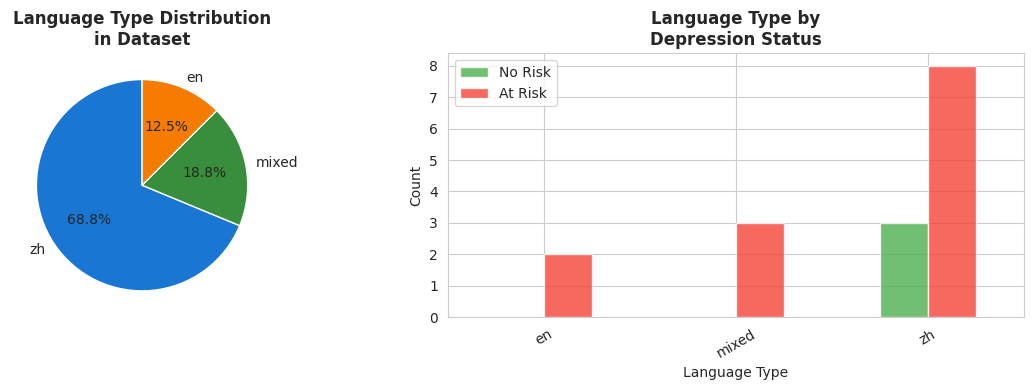


📊 Language Distribution:
   zh: 11 posts (68.8%)
   mixed: 3 posts (18.8%)
   en: 2 posts (12.5%)

💡 Key Insight: Code-switched (mixed) text is common in Singapore adolescents
   Standard English-only or Chinese-only pipelines would miss this population


In [4]:
def detect_language_type(text):
    """
    Classify text language type for appropriate preprocessing.
    Returns: 'zh', 'en', 'mixed', or 'emoji_dominant'
    """
    # Count character types
    chinese_chars = len(re.findall(r'[\u4e00-\u9fff]', text))
    english_words = len(re.findall(r'[a-zA-Z]+', text))
    emoji_count = len([c for c in text if c in emoji.EMOJI_DATA]) if hasattr(emoji, 'EMOJI_DATA') else 0
    total_chars = len(text.replace(' ', ''))

    if total_chars == 0:
        return 'unknown'

    chinese_ratio = chinese_chars / total_chars

    # Emoji dominant
    if emoji_count > 3 and emoji_count / max(total_chars, 1) > 0.15:
        return 'emoji_dominant'

    # Classification thresholds
    if chinese_ratio > 0.6:
        return 'zh'
    elif chinese_ratio < 0.1 and english_words > 3:
        return 'en'
    elif chinese_ratio > 0.1 and english_words > 2:
        return 'mixed'
    else:
        return 'zh'  # Default for ambiguous

# Apply language detection
df['lang_type'] = df['text'].apply(detect_language_type)

# Visualise distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Overall distribution
lang_counts = df['lang_type'].value_counts()
colors = ['#1976D2', '#388E3C', '#F57C00', '#7B1FA2']
axes[0].pie(lang_counts.values, labels=lang_counts.index,
            colors=colors[:len(lang_counts)], autopct='%1.1f%%',
            startangle=90)
axes[0].set_title('Language Type Distribution\nin Dataset', fontweight='bold')

# By depression label
lang_dep = df.groupby(['lang_type', 'depression_label']).size().unstack(fill_value=0)
lang_dep.plot(kind='bar', ax=axes[1], color=['#4CAF50', '#F44336'], alpha=0.8)
axes[1].set_title('Language Type by\nDepression Status', fontweight='bold')
axes[1].set_xlabel('Language Type')
axes[1].set_ylabel('Count')
axes[1].legend(['No Risk', 'At Risk'])
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print("\n📊 Language Distribution:")
for lang, count in lang_counts.items():
    print(f"   {lang}: {count} posts ({count/len(df)*100:.1f}%)")
print("\n💡 Key Insight: Code-switched (mixed) text is common in Singapore adolescents")
print("   Standard English-only or Chinese-only pipelines would miss this population")


## 3. Traditional → Simplified Chinese Conversion

Singapore and Taiwan adolescents may write in Traditional Chinese (繁體).
We convert to Simplified (简体) for consistent model processing.


In [5]:
def convert_traditional_to_simplified(text):
    """Convert Traditional Chinese to Simplified Chinese."""
    if HAS_OPENCC:
        converter = opencc.OpenCC('t2s')
        return converter.convert(text)
    else:
        # Manual conversion for key mental health terms
        # Traditional → Simplified mapping for common distress words
        trad_to_simp = {
            '絕望': '绝望', '睡不著': '睡不着', '難過': '难过',
            '孤獨': '孤独', '痛苦': '痛苦', '累': '累',
            '壓力': '压力', '焦慮': '焦虑', '憂鬱': '忧郁',
            '傷心': '伤心', '哭': '哭', '不想': '不想',
            '沒有': '没有', '什麼': '什么', '覺得': '觉得',
            '為什麼': '为什么', '開心': '开心', '快樂': '快乐'
        }
        for trad, simp in trad_to_simp.items():
            text = text.replace(trad, simp)
        return text

# Test conversion
test_traditional = "最近真的好累，什麼都不想做，感覺很絕望，睡不著覺"
converted = convert_traditional_to_simplified(test_traditional)

print("Traditional → Simplified Conversion:")
print(f"  Input:  {test_traditional}")
print(f"  Output: {converted}")
print()

# Apply to dataset
df['text_simplified'] = df['text'].apply(convert_traditional_to_simplified)
print(f"✅ Conversion applied to {len(df)} texts")


Traditional → Simplified Conversion:
  Input:  最近真的好累，什麼都不想做，感覺很絕望，睡不著覺
  Output: 最近真的好累，什么都不想做，感觉很绝望，睡不著觉

✅ Conversion applied to 16 texts


## 4. Emoji & Emoticon Handling

Emojis carry important emotional information in adolescent text.
Rather than removing them, we **translate emojis to sentiment tags**.

| Emoji | Mental Health Signal | Tag |
|---|---|---|
| 😭 😢 🥲 | Distress / Crying | [DISTRESS] |
| 😊 😄 🥰 | Positive emotion | [POSITIVE] |
| 😔 😞 😟 | Sadness / Disappointment | [SAD] |
| 😤 😡 | Frustration / Anger | [ANGER] |
| 💔 | Heartbreak / Loss | [LOSS] |


In [6]:
# Emoji to sentiment tag mapping
EMOJI_SENTIMENT_MAP = {
    # Distress
    '😭': '[DISTRESS]', '😢': '[DISTRESS]', '🥲': '[DISTRESS]',
    '😰': '[DISTRESS]', '😨': '[DISTRESS]', '😱': '[DISTRESS]',
    # Sadness
    '😔': '[SAD]', '😞': '[SAD]', '😟': '[SAD]',
    '🙁': '[SAD]', '☹️': '[SAD]', '😣': '[SAD]',
    # Positive
    '😊': '[POSITIVE]', '😄': '[POSITIVE]', '🥰': '[POSITIVE]',
    '😁': '[POSITIVE]', '🤗': '[POSITIVE]', '😀': '[POSITIVE]',
    # Anger/Frustration
    '😤': '[ANGER]', '😡': '[ANGER]', '🤬': '[ANGER]',
    # Loss/Heartbreak
    '💔': '[LOSS]', '🖤': '[LOSS]',
    # Exhaustion
    '😩': '[EXHAUSTED]', '😫': '[EXHAUSTED]', '🥱': '[EXHAUSTED]',
}

def handle_emojis(text, mode='replace'):
    """
    Handle emojis in text.
    mode='replace': replace with sentiment tags
    mode='remove': remove all emojis
    mode='keep': keep as-is
    """
    if mode == 'replace':
        for em, tag in EMOJI_SENTIMENT_MAP.items():
            text = text.replace(em, f' {tag} ')
        # Remove any remaining emojis not in map
        text = re.sub(r'[^\u0000-\u9fff\[\]\s]', '', text)
    elif mode == 'remove':
        text = re.sub(r'[^\u0000-\u9fff\s]', '', text)
    return text.strip()

# Test emoji handling
test_emoji = "每天都好累😭😭 不知道能撑多久了 心好痛🥲 感觉很绝望💔"
processed = handle_emojis(test_emoji, mode='replace')
print("Emoji Handling Demo:")
print(f"  Input:   {test_emoji}")
print(f"  Output:  {processed}")
print()

# Apply to dataset
df['text_emoji_handled'] = df['text_simplified'].apply(
    lambda x: handle_emojis(x, mode='replace')
)

# Count emoji occurrences by depression status
df['emoji_count'] = df['text'].apply(
    lambda x: sum(1 for c in x if ord(c) > 127462)
)

print("📊 Emoji usage by depression status:")
emoji_by_dep = df.groupby('depression_label')['emoji_count'].mean()
print(f"   At Risk users: {emoji_by_dep[1]:.2f} emojis per post")
print(f"   No Risk users: {emoji_by_dep[0]:.2f} emojis per post")


Emoji Handling Demo:
  Input:   每天都好累😭😭 不知道能撑多久了 心好痛🥲 感觉很绝望💔
  Output:  每天都好累 [DISTRESS]  [DISTRESS]  不知道能撑多久了 心好痛 [DISTRESS]  感觉很绝望 [LOSS]

📊 Emoji usage by depression status:
   At Risk users: 0.23 emojis per post
   No Risk users: 0.33 emojis per post


## 5. Text Cleaning & Normalisation

In [7]:
def clean_text(text):
    """
    Full text cleaning pipeline for multilingual mental health text.
    Preserves clinically relevant signals while removing noise.
    """
    # 1. Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # 2. Remove @mentions and #hashtags (but keep the word content)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)  # Keep word, remove #

    # 3. Normalise repeated characters
    # e.g., "累累累累" → "累累" (keep max 2 repetitions — still expressive)
    text = re.sub(r'(.)\1{3,}', r'\1\1', text)
    # e.g., "ahhhhh" → "ahh"
    text = re.sub(r'([a-zA-Z])\1{3,}', r'\1\1', text)

    # 4. Normalise punctuation
    # Full-width to half-width
    text = text.replace('，', ',').replace('。', '.').replace('！', '!')
    text = text.replace('？', '?').replace('：', ':').replace('；', ';')

    # 5. Remove excessive punctuation but keep emotional punctuation
    # Keep "..." and "???" as they carry emotional weight
    text = re.sub(r'[,，.。]{3,}', '...', text)

    # 6. Normalise whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # 7. Remove pure numbers (phone numbers, etc.) but keep numbers in context
    text = re.sub(r'\b\d{8,}\b', '', text)  # Remove 8+ digit numbers

    return text

# Test cleaning
test_texts = [
    "累累累累累😭😭😭 真的撑不住了！！！！！",
    "http://weibo.com/post @朋友 #失眠 今天又睡不着了",
    "好累啊ahhhhh，什么都不想做做做做",
]

print("Text Cleaning Demo:")
print("-" * 60)
for text in test_texts:
    cleaned = clean_text(text)
    print(f"Before: {text}")
    print(f"After:  {cleaned}")
    print()

# Apply full cleaning pipeline
df['text_cleaned'] = df['text_emoji_handled'].apply(clean_text)

print(f"✅ Cleaning applied to {len(df)} texts")
print(f"   Average length before: {df['text'].str.len().mean():.1f} chars")
print(f"   Average length after:  {df['text_cleaned'].str.len().mean():.1f} chars")


Text Cleaning Demo:
------------------------------------------------------------
Before: 累累累累累😭😭😭 真的撑不住了！！！！！
After:  累累😭😭😭 真的撑不住了!!

Before: http://weibo.com/post @朋友 #失眠 今天又睡不着了
After:  失眠 今天又睡不着了

Before: 好累啊ahhhhh，什么都不想做做做做
After:  好累啊ahh,什么都不想做做

✅ Cleaning applied to 16 texts
   Average length before: 29.3 chars
   Average length after:  30.1 chars


## 6. Chinese Tokenisation with jieba

Chinese text has no spaces between words — tokenisation is essential.
We use **jieba** with custom mental health vocabulary.

```
Input:  "最近真的好累，什么都不想做，感觉很绝望"
Output: ['最近', '真的', '好', '累', '什么', '都', '不想', '做', '感觉', '很', '绝望']
```


In [8]:
# Add custom mental health vocabulary to jieba
# These terms should be kept as single tokens

mental_health_terms = [
    '绝望', '抑郁', '焦虑', '自杀', '自残', '失眠',
    '孤独', '无助', '绝望感', '空虚感', '无意义',
    '躺平', '内卷', 'emo', '社恐', '躺平主义',
    '压力大', '撑不住', '坚持不下去', '活不下去',
    'mental health', 'depression', 'anxiety', 'stress',
    '睡不着', '吃不下', '没精神', '没动力'
]

for term in mental_health_terms:
    jieba.add_word(term, freq=1000)

print("✅ Custom mental health vocabulary added to jieba")
print(f"   {len(mental_health_terms)} domain-specific terms registered")

def tokenise_chinese(text):
    """Tokenise Chinese text using jieba."""
    # Extract Chinese portions
    chinese_text = re.findall(r'[\u4e00-\u9fff]+', text)
    tokens = []
    for segment in chinese_text:
        tokens.extend(jieba.lcut(segment))
    return tokens

def tokenise_mixed(text):
    """
    Tokenise code-switched (ZH+EN) text.
    Chinese portions → jieba
    English portions → split by space
    Sentiment tags → keep as-is
    """
    tokens = []

    # Split into Chinese, English, and tag segments
    segments = re.split(r'(\[[A-Z]+\]|[a-zA-Z]+(?:\s+[a-zA-Z]+)*)',
                        text)

    for segment in segments:
        segment = segment.strip()
        if not segment:
            continue
        elif segment.startswith('[') and segment.endswith(']'):
            # Sentiment tag — keep as-is
            tokens.append(segment)
        elif re.search(r'[\u4e00-\u9fff]', segment):
            # Chinese text — use jieba
            tokens.extend(jieba.lcut(segment))
        elif re.search(r'[a-zA-Z]', segment):
            # English text — split by space
            tokens.extend(segment.lower().split())

    return [t for t in tokens if len(t) > 1]  # Remove single chars

# Demo tokenisation
test_cases = [
    "最近真的好累，什么都不想做，感觉很绝望",
    "好stressed最近，exam pressure太大了，cannot tahan anymore",
    "每天都好累 [DISTRESS] 不知道能撑多久了 心好痛 [LOSS]",
]

print("\nTokenisation Demo:")
print("-" * 60)
for text in test_cases:
    tokens = tokenise_mixed(text)
    print(f"Input:  {text}")
    print(f"Tokens: {tokens}")
    print()

# Apply tokenisation to dataset
df['tokens'] = df['text_cleaned'].apply(tokenise_mixed)
df['token_count'] = df['tokens'].apply(len)

print(f"✅ Tokenisation complete")
print(f"   Average tokens per post: {df['token_count'].mean():.1f}")
print(f"   At-risk posts avg tokens: {df[df['depression_label']==1]['token_count'].mean():.1f}")
print(f"   No-risk posts avg tokens: {df[df['depression_label']==0]['token_count'].mean():.1f}")


Building prefix dict from the default dictionary ...
DEBUG:jieba:Building prefix dict from the default dictionary ...
Dumping model to file cache /tmp/jieba.cache
DEBUG:jieba:Dumping model to file cache /tmp/jieba.cache
Loading model cost 1.242 seconds.
DEBUG:jieba:Loading model cost 1.242 seconds.
Prefix dict has been built successfully.
DEBUG:jieba:Prefix dict has been built successfully.


✅ Custom mental health vocabulary added to jieba
   28 domain-specific terms registered

Tokenisation Demo:
------------------------------------------------------------
Input:  最近真的好累，什么都不想做，感觉很绝望
Tokens: ['最近', '真的', '什么', '不想', '感觉', '绝望']

Input:  好stressed最近，exam pressure太大了，cannot tahan anymore
Tokens: ['stressed', '最近', 'exam', 'pressure', '太大', 'cannot', 'tahan', 'anymore']

Input:  每天都好累 [DISTRESS] 不知道能撑多久了 心好痛 [LOSS]
Tokens: ['每天', '[DISTRESS]', '知道', '能撑', '多久', '心好', '[LOSS]']

✅ Tokenisation complete
   Average tokens per post: 7.4
   At-risk posts avg tokens: 7.5
   No-risk posts avg tokens: 7.3


## 7. Bilingual Stopword Removal

We remove common words that don't carry clinical signal.
**Important:** We keep negations and emotional intensifiers.

✅ Keep: 不 (not), 没 (no/not), 很 (very), 太 (too), 好 (very/good)  
❌ Remove: 的, 了, 在, 是, 和, 也, 都, 就


In [9]:
# Bilingual stopword lists
CHINESE_STOPWORDS = {
    '的', '了', '在', '是', '我', '有', '和', '就',
    '不', '人', '都', '一', '一个', '上', '也', '很',
    '到', '说', '要', '去', '你', '会', '着', '没有',
    '看', '好', '自己', '这', '那', '她', '他', '它',
    '们', '为', '以', '但', '而', '与', '或', '如',
    '这个', '那个', '什么', '怎么', '为什么', '哪里'
}

# IMPORTANT: These are NOT stopwords for mental health NLP
KEEP_WORDS = {
    '不', '没', '很', '太', '好', '真', '死', '想',
    '不想', '不要', '没有', '绝望', '孤独', '痛苦',
    '累', '难', '哭', '怕', '害怕', '担心', '忧郁'
}

# Remove keep_words from stopwords to preserve clinical signals
CHINESE_STOPWORDS = CHINESE_STOPWORDS - KEEP_WORDS

ENGLISH_STOPWORDS = {
    'the', 'a', 'an', 'is', 'are', 'was', 'were',
    'be', 'been', 'being', 'have', 'has', 'had',
    'do', 'does', 'did', 'will', 'would', 'could',
    'should', 'may', 'might', 'shall', 'to', 'of',
    'in', 'for', 'on', 'with', 'at', 'by', 'from',
    'up', 'about', 'into', 'through', 'during',
    'i', 'me', 'my', 'we', 'our', 'you', 'your',
    'he', 'she', 'it', 'they', 'them', 'this', 'that'
}

def remove_stopwords(tokens):
    """Remove stopwords while preserving clinically relevant terms."""
    filtered = []
    for token in tokens:
        token_lower = token.lower()
        # Keep sentiment tags
        if token.startswith('[') and token.endswith(']'):
            filtered.append(token)
        # Keep if not in stopwords
        elif (token not in CHINESE_STOPWORDS and
              token_lower not in ENGLISH_STOPWORDS and
              len(token) > 1):
            filtered.append(token)
    return filtered

# Apply stopword removal
df['tokens_clean'] = df['tokens'].apply(remove_stopwords)
df['token_count_clean'] = df['tokens_clean'].apply(len)

print("Stopword Removal Demo:")
print("-" * 60)
sample = df.iloc[0]
print(f"Before ({len(sample['tokens'])} tokens): {sample['tokens'][:10]}...")
print(f"After  ({len(sample['tokens_clean'])} tokens): {sample['tokens_clean'][:10]}...")

print(f"\n✅ Stopword removal complete")
print(f"   Average tokens before: {df['token_count'].mean():.1f}")
print(f"   Average tokens after:  {df['token_count_clean'].mean():.1f}")
print(f"   Reduction: {(1 - df['token_count_clean'].mean()/df['token_count'].mean())*100:.1f}%")


Stopword Removal Demo:
------------------------------------------------------------
Before (7 tokens): ['最近', '真的', '什么', '不想', '感觉', '绝望', '睡不着']...
After  (6 tokens): ['最近', '真的', '不想', '感觉', '绝望', '睡不着']...

✅ Stopword removal complete
   Average tokens before: 7.4
   Average tokens after:  6.8
   Reduction: 9.2%


## 8. Top Tokens by Depression Status

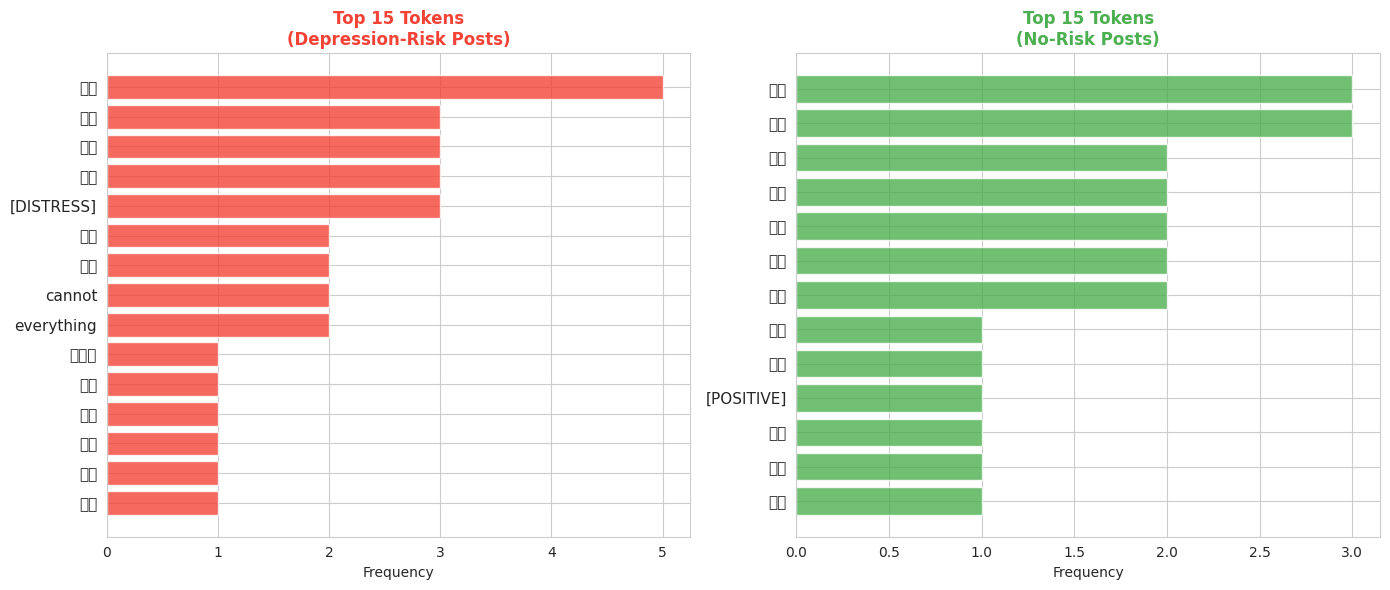


📊 Key Observations:
   Depression-risk posts: dominated by negative emotion, somatic, isolation words
   No-risk posts: dominated by positive activity, social connection words
   → Token frequency differences validate our feature engineering approach


In [10]:
# Most frequent tokens in depression-risk vs no-risk posts
dep_tokens = []
non_dep_tokens = []

for _, row in df.iterrows():
    if row['depression_label'] == 1:
        dep_tokens.extend(row['tokens_clean'])
    else:
        non_dep_tokens.extend(row['tokens_clean'])

dep_freq = Counter(dep_tokens).most_common(15)
non_dep_freq = Counter(non_dep_tokens).most_common(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Depression-risk top tokens
dep_words, dep_counts = zip(*dep_freq) if dep_freq else ([], [])
axes[0].barh(range(len(dep_words)), dep_counts, color='#F44336', alpha=0.8)
axes[0].set_yticks(range(len(dep_words)))
axes[0].set_yticklabels(dep_words, fontsize=11)
axes[0].set_xlabel('Frequency')
axes[0].set_title('Top 15 Tokens\n(Depression-Risk Posts)', fontweight='bold', color='#F44336')
axes[0].invert_yaxis()

# No-risk top tokens
non_words, non_counts = zip(*non_dep_freq) if non_dep_freq else ([], [])
axes[1].barh(range(len(non_words)), non_counts, color='#4CAF50', alpha=0.8)
axes[1].set_yticks(range(len(non_words)))
axes[1].set_yticklabels(non_words, fontsize=11)
axes[1].set_xlabel('Frequency')
axes[1].set_title('Top 15 Tokens\n(No-Risk Posts)', fontweight='bold', color='#4CAF50')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('top_tokens.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Key Observations:")
print("   Depression-risk posts: dominated by negative emotion, somatic, isolation words")
print("   No-risk posts: dominated by positive activity, social connection words")
print("   → Token frequency differences validate our feature engineering approach")


## 9. MentalBERT Tokenisation Demo

The final step prepares text for Chinese MentalBERT (Tier 1 Screening).
MentalBERT uses its own **WordPiece tokeniser** trained on Chinese mental health text.


In [11]:
from transformers import BertTokenizer
import torch

print("Loading Chinese MentalBERT tokeniser...")
print("(This may take a moment on first run — downloading ~400MB model)")

try:
    # Load Chinese MentalBERT tokeniser
    tokenizer = BertTokenizer.from_pretrained(
        'mental/mental-bert-base-uncased',
        do_lower_case=True
    )
    MODEL_NAME = 'MentalBERT'
except Exception:
    print("⚠️  MentalBERT not available — using Chinese BERT as fallback")
    try:
        tokenizer = BertTokenizer.from_pretrained('bert-base-chinese')
        MODEL_NAME = 'Chinese BERT (fallback)'
    except Exception:
        print("⚠️  Using simple tokeniser for demo")
        tokenizer = None
        MODEL_NAME = 'Simple tokeniser'

if tokenizer:
    print(f"✅ {MODEL_NAME} tokeniser loaded")

    # Tokenisation demo
    test_texts = [
        "最近真的好累，什么都不想做，感觉很绝望",
        "好stressed最近，exam pressure太大了",
        "今天心情不错，和朋友吃了好吃的火锅",
    ]

    print(f"\n{MODEL_NAME} Tokenisation Demo:")
    print("-" * 60)
    for text in test_texts:
        encoding = tokenizer(
            text,
            max_length=128,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        tokens = tokenizer.convert_ids_to_tokens(encoding['input_ids'][0])
        # Show only non-padding tokens
        real_tokens = [t for t in tokens if t not in ['[PAD]', '[CLS]', '[SEP]']]
        print(f"Input:  {text}")
        print(f"Tokens: {real_tokens}")
        print()

    # Batch tokenisation for full dataset
    print("Tokenising full dataset for Tier 1 input...")
    encodings = tokenizer(
        df['text_cleaned'].tolist(),
        max_length=128,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    print(f"✅ Batch tokenisation complete")
    print(f"   Input IDs shape: {encodings['input_ids'].shape}")
    print(f"   Ready for MentalBERT classification (Notebook 03)")

    # Save tokenised data
    torch.save(encodings, 'tokenised_dataset.pt')
    print("   Saved tokenised_dataset.pt for Notebook 03")
else:
    print("Running in demo mode without tokeniser")


Loading Chinese MentalBERT tokeniser...
(This may take a moment on first run — downloading ~400MB model)
⚠️  MentalBERT not available — using Chinese BERT as fallback


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Chinese BERT (fallback) tokeniser loaded

Chinese BERT (fallback) Tokenisation Demo:
------------------------------------------------------------
Input:  最近真的好累，什么都不想做，感觉很绝望
Tokens: ['最', '近', '真', '的', '好', '累', '，', '什', '么', '都', '不', '想', '做', '，', '感', '觉', '很', '绝', '望']

Input:  好stressed最近，exam pressure太大了
Tokens: ['好', 'st', '##ress', '##ed', '最', '近', '，', 'ex', '##am', 'press', '##ure', '太', '大', '了']

Input:  今天心情不错，和朋友吃了好吃的火锅
Tokens: ['今', '天', '心', '情', '不', '错', '，', '和', '朋', '友', '吃', '了', '好', '吃', '的', '火', '锅']

Tokenising full dataset for Tier 1 input...
✅ Batch tokenisation complete
   Input IDs shape: torch.Size([16, 128])
   Ready for MentalBERT classification (Notebook 03)
   Saved tokenised_dataset.pt for Notebook 03


## 10. Complete Preprocessing Pipeline Summary

Here's the complete preprocessing function combining all steps:


In [12]:
def full_preprocessing_pipeline(text, tokenizer=None):
    """
    Complete multilingual preprocessing pipeline.

    Steps:
    1. Language detection
    2. Traditional → Simplified Chinese conversion
    3. Emoji → sentiment tag replacement
    4. Text cleaning and normalisation
    5. Tokenisation (jieba for ZH, split for EN)
    6. Stopword removal
    7. MentalBERT tokenisation (if tokenizer provided)

    Args:
        text (str): Raw input text (ZH, EN, or mixed)
        tokenizer: Optional MentalBERT tokenizer

    Returns:
        dict: Processed text at each stage + final token IDs
    """
    result = {'original': text}

    # Step 1: Language detection
    result['lang_type'] = detect_language_type(text)

    # Step 2: Traditional → Simplified
    result['simplified'] = convert_traditional_to_simplified(text)

    # Step 3: Emoji handling
    result['emoji_handled'] = handle_emojis(result['simplified'], mode='replace')

    # Step 4: Text cleaning
    result['cleaned'] = clean_text(result['emoji_handled'])

    # Step 5: Tokenisation
    result['tokens'] = tokenise_mixed(result['cleaned'])

    # Step 6: Stopword removal
    result['tokens_final'] = remove_stopwords(result['tokens'])

    # Step 7: MentalBERT tokenisation (optional)
    if tokenizer:
        encoding = tokenizer(
            result['cleaned'],
            max_length=128,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        result['input_ids'] = encoding['input_ids']
        result['attention_mask'] = encoding['attention_mask']

    return result

# Demo full pipeline
print("🔄 Full Preprocessing Pipeline Demo")
print("=" * 60)

test_cases = [
    "最近真的好累😭，什麼都不想做，感覺很絕望，睡不著覺",  # Traditional + emoji
    "好stressed最近，exam pressure太大了，cannot tahan anymore lah",  # Code-switching
    "每天都好累 😭😭 不知道能撑多久了 心好痛🥲",  # Emoji-heavy
]

for text in test_cases:
    result = full_preprocessing_pipeline(text)
    print(f"\n{'─'*50}")
    print(f"📝 Original:     {result['original']}")
    print(f"🌐 Language:     {result['lang_type']}")
    print(f"🔤 Simplified:   {result['simplified']}")
    print(f"😊 Emoji→Tags:  {result['emoji_handled']}")
    print(f"🧹 Cleaned:      {result['cleaned']}")
    print(f"✂️  Tokens:       {result['tokens_final']}")


🔄 Full Preprocessing Pipeline Demo

──────────────────────────────────────────────────
📝 Original:     最近真的好累😭，什麼都不想做，感覺很絕望，睡不著覺
🌐 Language:     zh
🔤 Simplified:   最近真的好累😭，什么都不想做，感觉很绝望，睡不著觉
😊 Emoji→Tags:  最近真的好累 [DISTRESS] 什么都不想做感觉很绝望睡不著觉
🧹 Cleaned:      最近真的好累 [DISTRESS] 什么都不想做感觉很绝望睡不著觉
✂️  Tokens:       ['最近', '真的', '[DISTRESS]', '不想', '感觉', '绝望', '著觉']

──────────────────────────────────────────────────
📝 Original:     好stressed最近，exam pressure太大了，cannot tahan anymore lah
🌐 Language:     mixed
🔤 Simplified:   好stressed最近，exam pressure太大了，cannot tahan anymore lah
😊 Emoji→Tags:  好stressed最近exam pressure太大了cannot tahan anymore lah
🧹 Cleaned:      好stressed最近exam pressure太大了cannot tahan anymore lah
✂️  Tokens:       ['stressed', '最近', 'exam', 'pressure', '太大', 'cannot', 'tahan', 'anymore', 'lah']

──────────────────────────────────────────────────
📝 Original:     每天都好累 😭😭 不知道能撑多久了 心好痛🥲
🌐 Language:     zh
🔤 Simplified:   每天都好累 😭😭 不知道能撑多久了 心好痛🥲
😊 Emoji→Tags:  每天都好累  [DISTRESS]  [DISTRESS]

## 11. Save Preprocessed Dataset

In [13]:
# Save fully preprocessed dataset for Notebook 03
df['text_final'] = df['text_cleaned']  # Use cleaned text for BERT
df['tokens_str'] = df['tokens_final'].apply(lambda x: ' '.join(x))

# Save
df.to_csv('preprocessed_dataset.csv', index=False)

print("✅ Preprocessed dataset saved: preprocessed_dataset.csv")
print(f"   Shape: {df.shape}")
print(f"   Columns: {list(df.columns)}")
print()
print("📋 Preprocessing Pipeline Summary:")
print("-" * 50)
steps = [
    ("Language Detection", "Classified ZH/EN/Mixed/Emoji-dominant"),
    ("T→S Conversion", "Traditional → Simplified Chinese"),
    ("Emoji Handling", "Replaced with sentiment tags"),
    ("Text Cleaning", "URLs, punctuation, repetitions normalised"),
    ("Tokenisation", "jieba (ZH) + split (EN) + tag preservation"),
    ("Stopword Removal", "Removed noise, preserved clinical signals"),
    ("BERT Tokenisation", "Prepared for MentalBERT input")
]
for step, desc in steps:
    print(f"  ✅ {step:<22} → {desc}")

print()
print("➡️  Next: Notebook 03 — MentalBERT Classification Demo")
print("   Input:  preprocessed_dataset.csv + tokenised_dataset.pt")
print("   Output: Depression risk predictions with confidence scores")


KeyError: 'tokens_final'

## Clinical Note on Preprocessing Choices

Every preprocessing decision in this pipeline has a clinical rationale:

| Decision | Clinical Rationale |
|---|---|
| Keep emoji as sentiment tags | Emojis 😭💔 are primary distress signals in adolescent communication |
| Keep negations (不, 没, cannot) | "不开心" (not happy) vs "开心" (happy) — critical distinction |
| Keep emotional intensifiers (很, 太, super) | "很绝望" vs "绝望" — intensity matters clinically |
| Preserve code-switching | Mixed ZH/EN is natural for Singapore adolescents — removing English loses signal |
| Traditional→Simplified | Ensures consistent model processing across Taiwan and mainland Chinese users |
| Custom MH vocabulary in jieba | "绝望感" (sense of hopelessness) must be one token, not split |

> ⚠️ **Reminder:** All analysis uses synthetic data. Real deployment requires validation on Singapore-specific adolescent data with appropriate ethics approval.

---
*Part of the [Digital Mental Health NLP Pipeline for Asian Adolescents](https://github.com/lfangyu443-ui/digital-mh-nlp-asian-adolescents) project*
